In [1]:
# %pip install -r requirements.txt

Selected year: 2023


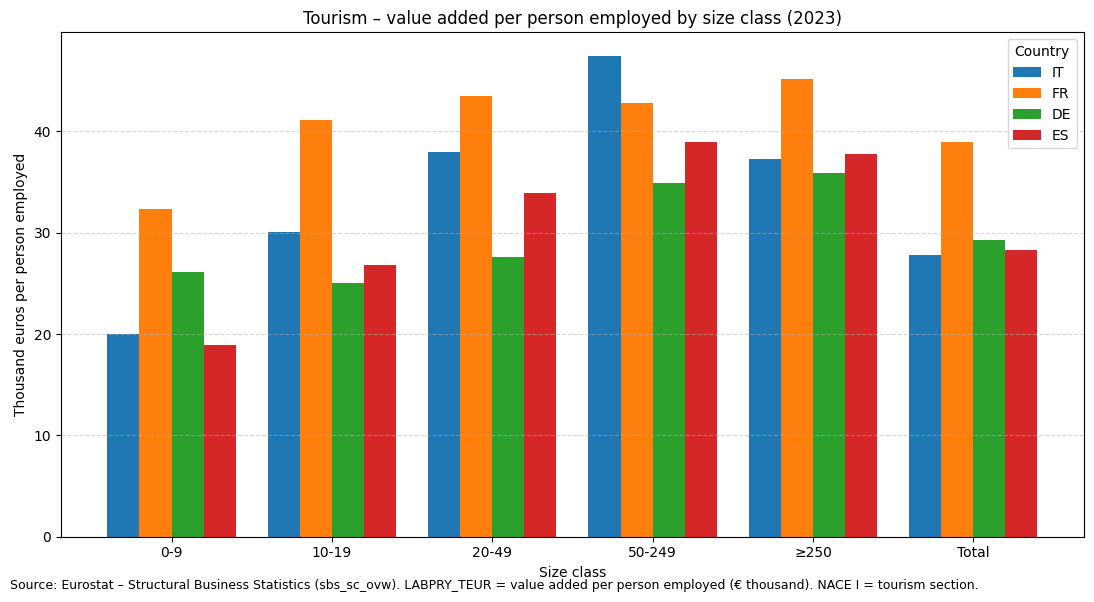

In [2]:
import eurostat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATASET = "sbs_sc_ovw"
countries = ["IT", "FR", "DE", "ES"]
size_order = ["0-9", "10-19", "20-49", "50-249", "GE250", "TOTAL"]
geo_col = "geo\\TIME_PERIOD"

IND_LAB = "LABPRY_TEUR"  # value added per person employed (€ thousand), average, not additive
NACE_I = "I"             # Tourism: section I

df = eurostat.get_data_df(DATASET)

year_cols = [c for c in df.columns if c.isdigit() and len(c) == 4]
year_cols.sort()

base = df[
    (df[geo_col].isin(countries)) &
    (df["nace_r2"] == NACE_I) &
    (df["size_emp"].isin(size_order)) &
    (df["indic_sbs"] == IND_LAB)
].copy()

# Find latest year with data available for the selected countries and size classes
def latest_available_year(base, year_cols, countries, size_order):
    for y in reversed(year_cols):
        tmp = base[[geo_col, "size_emp", y]].copy()
        tmp[y] = pd.to_numeric(tmp[y], errors="coerce")

        pivot = tmp.pivot(index="size_emp", columns=geo_col, values=y)

        if all(c in pivot.columns for c in countries) and all(s in pivot.index for s in size_order):
            selected = pivot.loc[size_order, countries]
            if selected.notna().any().any():
                return y

    raise ValueError("No year with available data found.")

year = latest_available_year(base, year_cols, countries, size_order)
print("Selected year:", year)

base[year] = pd.to_numeric(base[year], errors="coerce")
base["size_emp"] = pd.Categorical(base["size_emp"], categories=size_order, ordered=True)

pivot_lab = base.pivot(index="size_emp", columns=geo_col, values=year).loc[size_order, countries]
pivot_lab = pivot_lab.rename(index={"GE250": "≥250", "TOTAL": "Total"})

# Drop rows where all countries have missing values
pivot_lab = pivot_lab.dropna(how="all")

# --- Grouped bar chart ---
X = np.arange(len(pivot_lab.index))
m = len(pivot_lab.columns)
width = 0.8 / m

fig, ax = plt.subplots(figsize=(11, 6))

for j, col in enumerate(pivot_lab.columns):
    ax.bar(
        X + (j - (m - 1) / 2) * width,
        pivot_lab[col].values,
        width,
        label=col
    )

ax.set_xticks(X)
ax.set_xticklabels(pivot_lab.index)
ax.set_ylabel("Thousand euros per person employed")
ax.set_xlabel("Size class")
ax.set_title(f"Tourism – value added per person employed by size class ({year})")
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(title="Country")

fig.tight_layout()
fig.text(
    0.01,
    0.01,
    (
        "Source: Eurostat – Structural Business Statistics (sbs_sc_ovw). "
        "LABPRY_TEUR = value added per person employed (€ thousand). "
        "NACE I = tourism section."
    ),
    ha="left",
    fontsize=9
)

plt.show()

Selected year: 2023
Sector comparison – Italy, 2023
Sector
Energy                   385.67
Pharmaceuticals          167.80
Chemicals                121.44
Automotive               113.45
Aerospace/transport      103.14
Electronics               89.85
ICT                       85.00
Scientific research       75.58
National average          63.22
Professional services     52.69
Tourism                   27.81
Name: 2023, dtype: float64


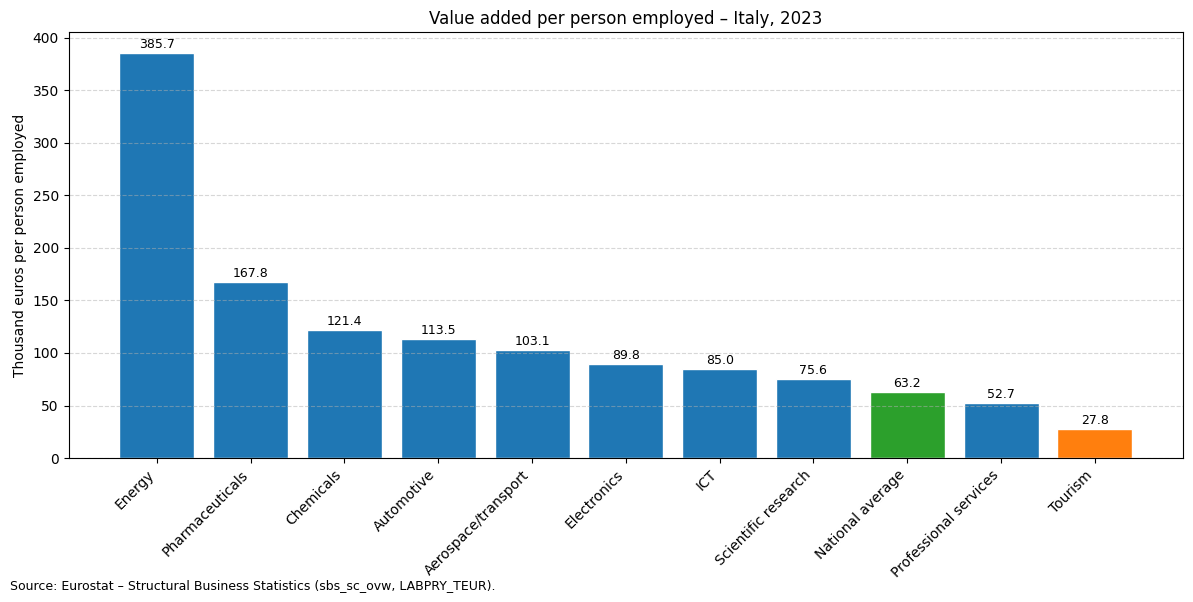

In [4]:
import eurostat
import pandas as pd
import matplotlib.pyplot as plt

DATASET = "sbs_sc_ovw"
GEO_COL = "geo\\TIME_PERIOD"
INDICATOR = "LABPRY_TEUR"  # value added per person employed (€ thousand)
TOTAL_ECONOMY = "B-S_X_O_S94"

# Selected sectors
sectors = {
    "I": "Tourism",
    "D": "Energy",
    "C20": "Chemicals",
    "C21": "Pharmaceuticals",
    "C26": "Electronics",
    "C29": "Automotive",
    "C30": "Aerospace/transport",
    "J": "ICT",
    "M72": "Scientific research",
    "M69": "Professional services"
}

# Download data from Eurostat
df = eurostat.get_data_df(DATASET)

year_cols = [c for c in df.columns if c.isdigit() and len(c) == 4]
year_cols.sort()

def latest_available_year(df, geo, sectors, total_economy, indicator, year_cols):
    required_nace = list(sectors.keys()) + [total_economy]

    for year in reversed(year_cols):
        tmp = df[
            (df[GEO_COL] == geo) &
            (df["indic_sbs"] == indicator) &
            (df["nace_r2"].isin(required_nace)) &
            (df["size_emp"] == "TOTAL")
        ][["nace_r2", year]].copy()

        tmp[year] = pd.to_numeric(tmp[year], errors="coerce")

        available_nace = set(tmp.loc[tmp[year].notna(), "nace_r2"])

        if total_economy in available_nace and any(s in available_nace for s in sectors.keys()):
            return year

    raise ValueError("No year with available data found.")

YEAR = latest_available_year(
    df=df,
    geo="IT",
    sectors=sectors,
    total_economy=TOTAL_ECONOMY,
    indicator=INDICATOR,
    year_cols=year_cols
)

print("Selected year:", YEAR)

# Filter Italy, selected sectors and indicator
base = df[
    (df[GEO_COL] == "IT") &
    (df["indic_sbs"] == INDICATOR) &
    (df["nace_r2"].isin(sectors.keys())) &
    (df["size_emp"] == "TOTAL")
].copy()

base[YEAR] = pd.to_numeric(base[YEAR], errors="coerce")
base["Sector"] = base["nace_r2"].map(sectors)

# National average, total economy
total = df[
    (df[GEO_COL] == "IT") &
    (df["indic_sbs"] == INDICATOR) &
    (df["nace_r2"] == TOTAL_ECONOMY) &
    (df["size_emp"] == "TOTAL")
].copy()

total[YEAR] = pd.to_numeric(total[YEAR], errors="coerce")
national_average = float(total[YEAR].dropna().iloc[0])

# Add national average
extra = pd.DataFrame([{
    "Sector": "National average",
    YEAR: national_average
}])

base = pd.concat([base[["Sector", YEAR]], extra], ignore_index=True)

# Sort results
res = (
    base
    .dropna(subset=[YEAR])
    .set_index("Sector")[YEAR]
    .sort_values(ascending=False)
)

print(f"Sector comparison – Italy, {YEAR}")
print(res)

# Chart
fig, ax = plt.subplots(figsize=(12, 6))

colors = [
    "#ff7f0e" if s == "Tourism" else
    "#2ca02c" if s == "National average" else
    "#1f77b4"
    for s in res.index
]

bars = ax.bar(res.index, res.values, color=colors, edgecolor="white")

# Value labels
for b, v in zip(bars, res.values):
    ax.text(
        b.get_x() + b.get_width() / 2,
        v + 2,
        f"{v:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title(f"Value added per person employed – Italy, {YEAR}")
ax.set_ylabel("Thousand euros per person employed")
ax.set_xticks(range(len(res.index)))
ax.set_xticklabels(res.index, rotation=45, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.5)

fig.tight_layout()
fig.text(
    0.01,
    0.01,
    "Source: Eurostat – Structural Business Statistics (sbs_sc_ovw, LABPRY_TEUR).",
    ha="left",
    fontsize=9
)

plt.show()

Selected year: 2023
Available macro-sectors, Italy, value added per person employed (€ thousand), 2023
Energy                                    385.7
Mining and quarrying                      153.4
Information and communication              85.0
Manufacturing                              81.9
Water and waste                            79.8
Real estate                                77.3
Transport and storage                      63.2
Arts, sports and entertainment             60.9
Construction                               59.6
Professional and scientific activities     56.8
Wholesale and retail trade; repair         52.9
Administrative and support services        38.8
Accommodation and food services            27.8
National average                           63.2
dtype: float64


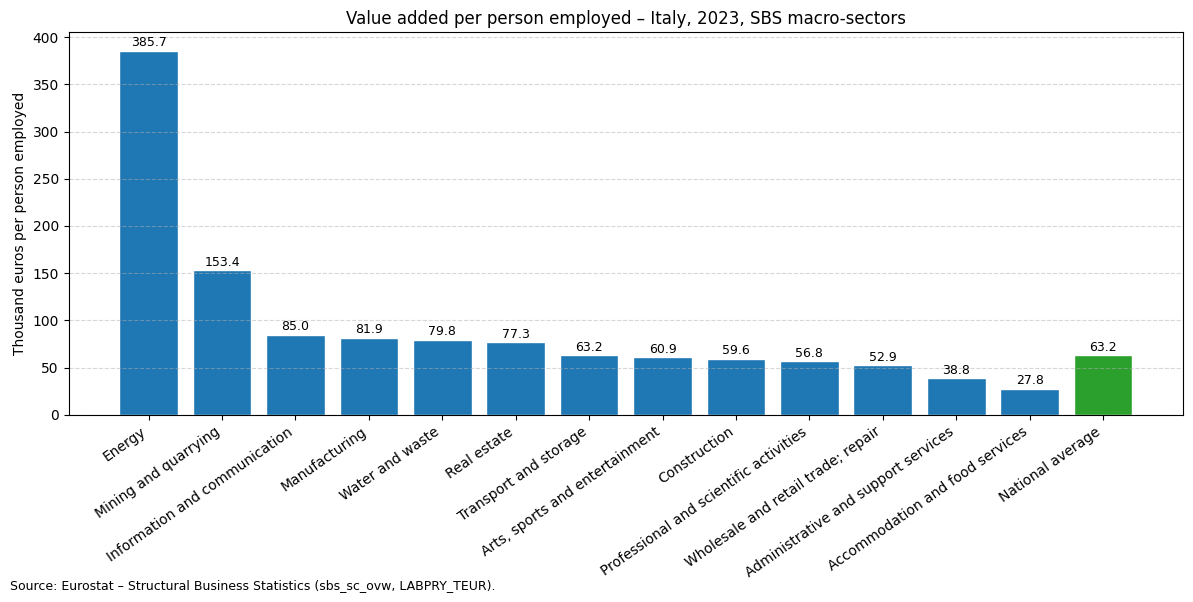

In [7]:
import eurostat
import pandas as pd
import matplotlib.pyplot as plt

DATASET = "sbs_sc_ovw"
GEO_COL = "geo\\TIME_PERIOD"
INDICATOR = "LABPRY_TEUR"  # € thousand per person employed
TOTAL_ECONOMY = "B-S_X_O_S94"

# Readable labels for SBS macro-sectors
labels = {
    "B": "Mining and quarrying",
    "C": "Manufacturing",
    "D": "Energy",
    "E": "Water and waste",
    "F": "Construction",
    "G": "Wholesale and retail trade; repair",
    "H": "Transport and storage",
    "I": "Accommodation and food services",
    "J": "Information and communication",
    "L": "Real estate",
    "M": "Professional and scientific activities",
    "N": "Administrative and support services",
    "R": "Arts, sports and entertainment",
    "S": "Other services"
}

excluded = {"A", "K", "O", "P", "Q", "T", "U"}  # outside SBS coverage

# 1) Download data from Eurostat
df = eurostat.get_data_df(DATASET)

year_cols = [c for c in df.columns if c.isdigit() and len(c) == 4]
year_cols.sort()

def latest_available_year(df, geo, indicator, labels, total_economy, year_cols):
    required_nace = list(labels.keys()) + [total_economy]

    for year in reversed(year_cols):
        tmp = df[
            (df[GEO_COL] == geo) &
            (df["indic_sbs"] == indicator) &
            (df["size_emp"] == "TOTAL") &
            (df["nace_r2"].isin(required_nace))
        ][["nace_r2", year]].copy()

        tmp[year] = pd.to_numeric(tmp[year], errors="coerce")
        available_nace = set(tmp.loc[tmp[year].notna(), "nace_r2"])

        if total_economy in available_nace and any(s in available_nace for s in labels.keys()):
            return year

    raise ValueError("No year with available data found.")

YEAR = latest_available_year(
    df=df,
    geo="IT",
    indicator=INDICATOR,
    labels=labels,
    total_economy=TOTAL_ECONOMY,
    year_cols=year_cols
)

print("Selected year:", YEAR)

# 2) Filter Italy, indicator and total employment-size class
base = df[
    (df[GEO_COL] == "IT") &
    (df["indic_sbs"] == INDICATOR) &
    (df["size_emp"] == "TOTAL")
].copy()

# 3) Keep only one-letter macro-sectors available in SBS and exclude sectors outside SBS coverage
base = base[base["nace_r2"].str.len() == 1]
base = base[~base["nace_r2"].isin(excluded)]

# 4) Numeric conversion and label mapping
base[YEAR] = pd.to_numeric(base[YEAR], errors="coerce")
base = base.dropna(subset=[YEAR])
base["Sector"] = base["nace_r2"].map(labels).fillna(base["nace_r2"])

# 5) National average, total business economy
total = df[
    (df[GEO_COL] == "IT") &
    (df["indic_sbs"] == INDICATOR) &
    (df["nace_r2"] == TOTAL_ECONOMY) &
    (df["size_emp"] == "TOTAL")
].copy()

total[YEAR] = pd.to_numeric(total[YEAR], errors="coerce")
national_average = float(total[YEAR].dropna().iloc[0])

# 6) Sort series and add national average
res = (
    base[["Sector", YEAR]]
    .set_index("Sector")[YEAR]
    .sort_values(ascending=False)
)

res = pd.concat([res, pd.Series({"National average": national_average})])

# Quick check
print(f"Available macro-sectors, Italy, value added per person employed (€ thousand), {YEAR}")
print(res.round(1))

# 7) Chart
fig, ax = plt.subplots(figsize=(12, 6))

colors = [
    "#2ca02c" if i == "National average" else "#1f77b4"
    for i in res.index
]

bars = ax.bar(res.index, res.values, color=colors, edgecolor="white")

# Value labels
for b, v in zip(bars, res.values):
    ax.text(
        b.get_x() + b.get_width() / 2,
        v + 1.5,
        f"{v:.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=0
    )

ax.set_title(f"Value added per person employed – Italy, {YEAR}, SBS macro-sectors")
ax.set_ylabel("Thousand euros per person employed")
ax.set_xticks(range(len(res.index)))
ax.set_xticklabels(res.index, rotation=35, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

fig.text(
    0.01,
    0.01,
    "Source: Eurostat – Structural Business Statistics (sbs_sc_ovw, LABPRY_TEUR).",
    ha="left",
    fontsize=9
)

plt.show()